In [1]:
!pip install lightgbm

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn import svm
import optuna
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import t

In [3]:
import openml
import pandas as pd

dataset = openml.datasets.get_dataset(42372)

X, y, _, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

d = pd.concat([X, y], axis=1)
data = pd.DataFrame(d)

print(data.head())

print(len(data))

Could not download file from https://openml.org/datasets/0004/42372/dataset_42372.pq: HTTPSConnectionPool(host='www.openml.org', port=443): Max retries exceeded with url: https://www.openml.org/datasets/0004/42372/dataset_42372.pq (Caused by ResponseError('too many redirects'))


   Displacement  Horse_power  Weight  Acceleration  Model_year   Mpg
0          91.0           70  1955.0          20.5          71  26.0
1         232.0          100  2789.0          15.0          73  18.0
2         350.0          145  4055.0          12.0          76  13.0
3         318.0          140  4080.0          13.7          78  17.5
4         113.0           95  2372.0          15.0          70  24.0
392


<Axes: >

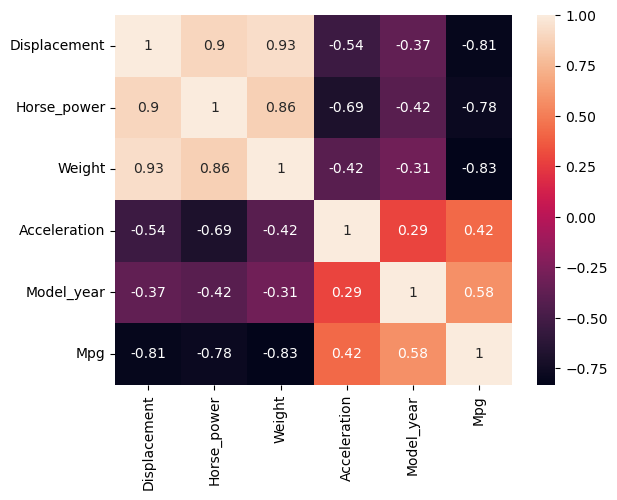

In [4]:
sns.heatmap(data.corr(), annot=True)

In [5]:
data.dtypes

Displacement    float64
Horse_power       uint8
Weight          float64
Acceleration    float64
Model_year        uint8
Mpg             float64
dtype: object

In [6]:
y = data["Mpg"]
X = data.drop("Mpg", axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
cv = KFold(n_splits = 5, shuffle=True, random_state=42)

n_feat_total = X_train.shape[1]
X_train

,Displacement,Horse_power,Weight,Acceleration,Model_year
258,400.0,150,4997.0,14.0,73
182,232.0,100,2914.0,16.0,75
172,183.0,77,3530.0,20.1,79
63,98.0,83,2219.0,16.5,74
340,113.0,95,2278.0,15.5,72
...,...,...,...,...,...
71,79.0,67,1950.0,19.0,74
106,163.0,125,3140.0,13.6,78
270,90.0,70,1937.0,14.0,75
348,225.0,100,3233.0,15.4,76


In [7]:
all_trial_scores = []

def objective(trial):
    # hiperparametry potrzebne w zadaniu
    
    n_features = trial.suggest_int("n_features", 3, n_feat_total)
    
    model_choice = trial.suggest_categorical("model", ["XGBoost", "LightGBM"])
        
    
    common_params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42
    }

    if model_choice == "LightGBM":
        common_params["num_leaves"] = trial.suggest_int("num_leaves", 20, 100)

    models = {
        "XGBoost": XGBRegressor,
        "LightGBM": LGBMRegressor
    }
    

    model = models[model_choice](**common_params)


    pipeline = Pipeline([
        ('scaler', StandardScaler()), # skaluje cechy do sredniej = 0 i odchylenia_stand = 1
        ("var_thresh", VarianceThreshold()), #  removing features with low variance.
        ("kbest", SelectKBest(score_func=f_regression, k=n_features)), # f_regression to funkcja ktora mierzy P_val i stat F, 
        # a statystyka F jest liczona wg wzoru: F = wariancja wyjasniona przez ceche / wariancja niewyjasniona
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, Y_train, cv = cv, scoring = "r2")
    all_trial_scores.append(scores)
    return scores.mean()



In [8]:
study = optuna.create_study(
    direction="maximize", 
    sampler = TPESampler(seed=42) # to mowi nam o tym jakie kombinacje hiperparametrow wybrac w kolejnych trialach
    # direction szuka najlepszego mozliwego wyniku, a sampler mowi zeby szukac za pomoca jakis wzorcow
)
all_trial_scores = []

def objective_wrapper(trial):
    scores = objective(trial)
    all_trial_scores.append(scores)
    return np.mean(scores)


study.optimize(objective_wrapper, n_trials=25)


print("Best Val: ", study.best_value)
print("Best params: ", study.best_params)

[I 2025-11-30 11:12:33,183] A new study created in memory with name: no-name-aa3d826e-49b3-4c79-915f-643199baa42a
[I 2025-11-30 11:12:33,759] Trial 0 finished with value: 0.851386392615699 and parameters: {'n_features': 4, 'model': 'XGBoost', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.055238410897498764, 'subsample': 0.6232334448672797, 'colsample_bytree': 0.9464704583099741}. Best is trial 0 with value: 0.851386392615699.
[I 2025-11-30 11:12:34,930] Trial 1 finished with value: 0.8349819191660963 and parameters: {'n_features': 4, 'model': 'XGBoost', 'n_estimators': 293, 'max_depth': 9, 'learning_rate': 0.07157834209670008, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735}. Best is trial 0 with value: 0.851386392615699.
[I 2025-11-30 11:12:35,316] Trial 2 finished with value: 0.76045968149008 and parameters: {'n_features': 3, 'model': 'XGBoost', 'n_estimators': 123, 'max_depth': 7, 'learning_rate': 0.05045321958909213, 'subsample': 0.7168578594140873

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 250, number of used features: 3
[LightGBM] [Info] Start training from score 23.202000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-11-30 11:12:36,259] Trial 4 finished with value: 0.725421104328773 and parameters: {'n_features': 3, 'model': 'LightGBM', 'n_estimators': 252, 'max_depth': 5, 'learning_rate': 0.03832491306185132, 'subsample': 0.8736932106048627, 'colsample_bytree': 0.7760609974958406, 'num_leaves': 29}. Best is trial 0 with value: 0.851386392615699.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-11-30 11:12:36,468] Trial 5 fini

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 229
[LightGBM] [Info] Number of data points in the train set: 250, number of used features: 5
[LightGBM] [Info] Start training from score 23.208000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-11-30 11:12:40,976] Trial 22 finished with value: 0.8502162229815949 and parameters: {'n_features': 5, 'model': 'LightGBM', 'n_estimators': 75, 'max_depth': 4, 'learning_rate': 0.23005285269222434, 'subsample': 0.9508096412230284, 'colsample_bytree': 0.6382247020969257, 'num_leaves': 51}. Best is trial 8 with value: 0.852593987600591.
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: Us

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-11-30 11:12:41,343] Trial 24 fin

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [9]:
xgb_scores = []
lgbm_scores = []
xgb_params = []
lgbm_params = []

for i, trial in enumerate(study.trials):
    scores = all_trial_scores[i]
    model_type = trial.params["model"]
    
    if model_type == "LightGBM":
        lgbm_scores.append(scores)
        lgbm_params.append(trial.params)
    else:
        xgb_scores.append(scores)
        xgb_params.append(trial.params)


In [10]:
xgb_mean_scores = [np.mean(s) for s in xgb_scores]
best_xgb_idx = np.argmax(xgb_mean_scores)
best_xgb_cv = xgb_scores[best_xgb_idx]
best_xgb_params = xgb_params[best_xgb_idx]

# SVR
lgbm_mean_scores = [np.mean(s) for s in lgbm_scores]
best_lgbm_idx = np.argmax(lgbm_mean_scores)
best_lgbm_cv = lgbm_scores[best_lgbm_idx]
best_lgbm_params = lgbm_params[best_lgbm_idx]

print("Best XGB CV: ", best_xgb_cv)
print("Best XGB params: ", best_xgb_params)
print("Best LGBM CV: ", best_lgbm_cv)
print("Best LGBM params: ", best_lgbm_params)

Best XGB CV:  [0.84391017 0.86395563 0.86923994 0.90222383 0.77760239]
Best XGB params:  {'n_features': 4, 'model': 'XGBoost', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.055238410897498764, 'subsample': 0.6232334448672797, 'colsample_bytree': 0.9464704583099741}
Best LGBM CV:  [0.84461678 0.83575705 0.86875117 0.91457813 0.79926681]
Best LGBM params:  {'n_features': 4, 'model': 'LightGBM', 'n_estimators': 143, 'max_depth': 9, 'learning_rate': 0.29720082313915164, 'subsample': 0.6831691628659669, 'colsample_bytree': 0.7279490294387551, 'num_leaves': 46}


In [15]:
best_xgb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("var_thresh", VarianceThreshold(threshold=0.0)), #  Variance Threshold is a simple technique that removes all features whose variance does not meet a specified threshold.
    ("kbest", SelectKBest(score_func=f_regression, k=best_xgb_params["n_features"])),
    ("model", XGBRegressor(
        n_estimators=best_xgb_params["n_estimators"],
        max_depth=best_xgb_params["max_depth"],
        learning_rate=best_xgb_params["learning_rate"],
        subsample=best_xgb_params["subsample"],
        colsample_bytree=best_xgb_params["colsample_bytree"],
        random_state=42,
    ),)
])

best_xgb_model.fit(X_train, Y_train)
y_pred_xgb = best_xgb_model.predict(X_test)
print("XGB R2:", r2_score(Y_test, y_pred_xgb))
print("XGB MSE:", mean_squared_error(Y_test, y_pred_xgb))

XGB R2: 0.8670723167857337
XGB MSE: 6.840397662780089


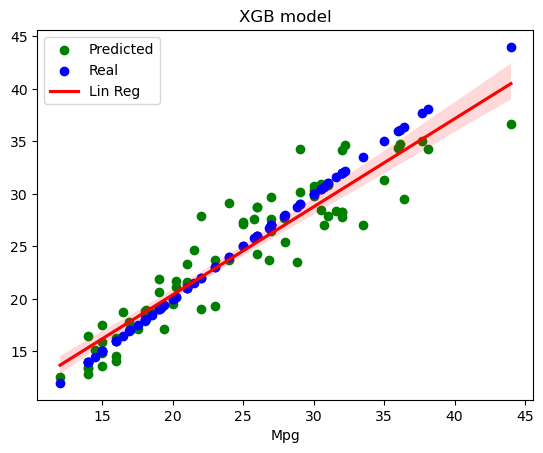

In [31]:
def plot_model(y_pred, title):
    plt.scatter(Y_test, y_pred, color="g", label="Predicted")
    plt.scatter(Y_test, Y_test, color="b", label="Real")
    sns.regplot(x=Y_test, y=y_pred, color="red", order=1, scatter=False, label="Lin Reg")
    plt.legend()
    
    plt.title(title)
    plt.show()    

plot_model(y_pred_xgb, "XGB model")

In [24]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


best_lgbm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("var_thresh", VarianceThreshold(threshold=0.0)), #  Variance Threshold is a simple technique that removes all features whose variance does not meet a specified threshold.
    ("kbest", SelectKBest(score_func=f_regression, k=best_lgbm_params["n_features"])),
    ("model", LGBMRegressor(
        n_estimators=best_lgbm_params["n_estimators"],
        max_depth=best_lgbm_params["max_depth"],
        learning_rate=best_lgbm_params["learning_rate"],
        subsample=best_lgbm_params["subsample"],
        colsample_bytree=best_lgbm_params["colsample_bytree"],
        num_leaves = best_lgbm_params["num_leaves"],
        random_state=42,
    ),)
])

best_lgbm_model.fit(X_train, Y_train)
y_pred_lgbm = best_lgbm_model.predict(X_test)
print("LGBM R2:", r2_score(Y_test, y_pred_lgbm))
print("LGBM MSE:", mean_squared_error(Y_test, y_pred_lgbm))


# blad Lgbm mowi, ze podczas budowy drzewa nie znalazl zadnego podzialu, ktory poprawilby wynik

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 313, number of used features: 4
[LightGBM] [Info] Start training from score 23.257827
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

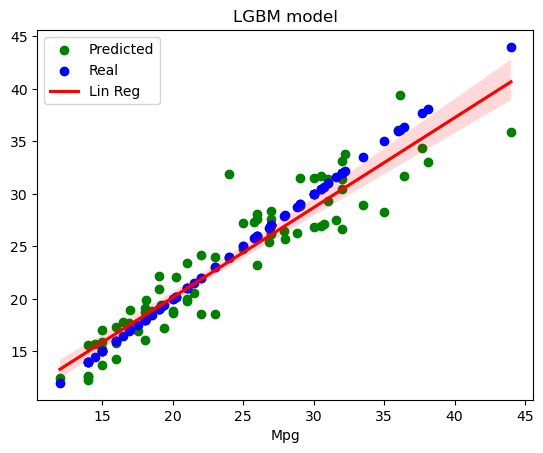

In [32]:
plot_model(y_pred_lgbm, "LGBM model")

In [47]:
def wilcoxon_test(model1, model2):
    stat, p = wilcoxon(model1, model2)
    print("stats: ", stat)
    print("P val: ", p)

In [52]:
wilcoxon_test(y_pred_lgbm, y_pred_xgb)
# roznica jest statystycznie istotna, (Ale nie mowi nam to wprost czy jeden model jest lepszy od drugiego)
# z tego powodu trzeba sprawdzic jakis inny parametr, np. sredni blad albo metryke


stats:  1315.0
P val:  0.19529489958850776


stats:  1503.0
P val:  0.7066906418703246


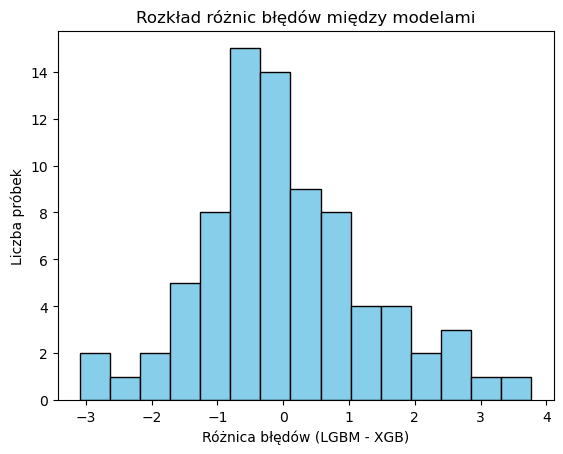

In [70]:
# drugi sposob na test wilcoxona
err_xgb = abs(Y_test - y_pred_xgb)
err_lgbm = abs(Y_test - y_pred_lgbm)

wilcoxon_test(err_xgb, err_lgbm)
# z tego wniosek, ze model NIE ma istotnie mniejszego bledu niz drugi model 

diff = err_xgb - err_lgbm


plt.hist(diff, bins=15, color="skyblue", edgecolor="k")
plt.xlabel("Różnica błędów (LGBM - XGB)")
plt.ylabel("Liczba próbek")
plt.title("Rozkład różnic błędów między modelami")
# wilcoxon nie jest testem parametrycznym, wiec jego statystyka nie moze byc dokladnie t-studentem
plt.show()




In [55]:
print("MAE LGBM:", np.mean(err_lgbm))
print("MAE XGB:", np.mean(err_xgb))

# teraz wniosek ze roznica jest statystycznie istotna, a LGBM ma nizszy blad, wiec warto go uzywac w tym przypadku.

MAE LGBM: 1.9282738288752568
MAE XGB: 1.9589920744111264
